# K-Nearest Neighbors (KNN) Classification on Iris Dataset

This notebook trains a KNN classifier on the Iris dataset, evaluates accuracy for different values of K, and visualizes the best model's confusion matrix.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style('whitegrid')

In [2]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')
label_map = dict(enumerate(iris.target_names))

print('Feature preview:')
print(X.head())
print('')
print('Target distribution:')
print(y.map(label_map).value_counts())

Feature preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target distribution:
target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Data Scaling and Train/Test Split

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)

Training set shape: (120, 4)
Testing set shape: (30, 4)


## Model Tuning: Accuracy vs K

In [4]:
k_values = list(range(1, 16))
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

results = pd.DataFrame({'K': k_values, 'Accuracy': accuracies})
print(results)

     K  Accuracy
0    1  0.966667
1    2  0.933333
2    3  0.933333
3    4  0.933333
4    5  0.933333
5    6  0.933333
6    7  0.966667
7    8  0.933333
8    9  0.966667
9   10  0.966667
10  11  0.966667
11  12  0.966667
12  13  0.966667
13  14  0.933333
14  15  0.933333


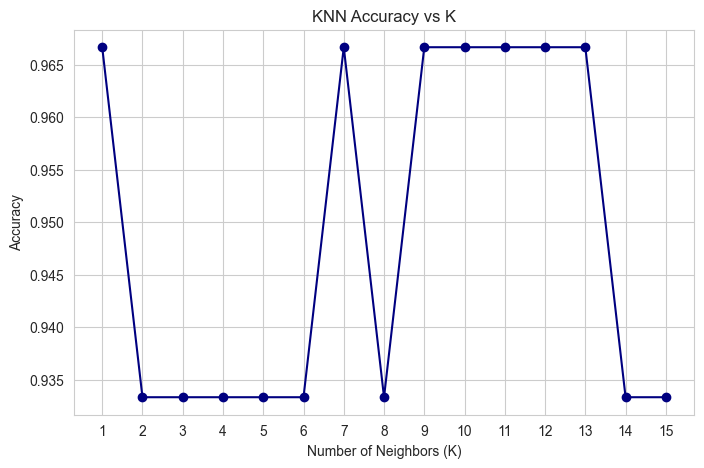

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(results['K'], results['Accuracy'], marker='o', color='navy')
plt.xticks(k_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K')
plt.grid(True)
plt.show()

## Best K Evaluation

In [6]:
best_k = int(results.loc[results['Accuracy'].idxmax(), 'K'])
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
y_pred_best = best_knn.predict(X_test)

print(f'Best K: {best_k}')
print('Accuracy:', accuracy_score(y_test, y_pred_best))
print('Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=iris.target_names))

Best K: 1
Accuracy: 0.9666666666666667
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



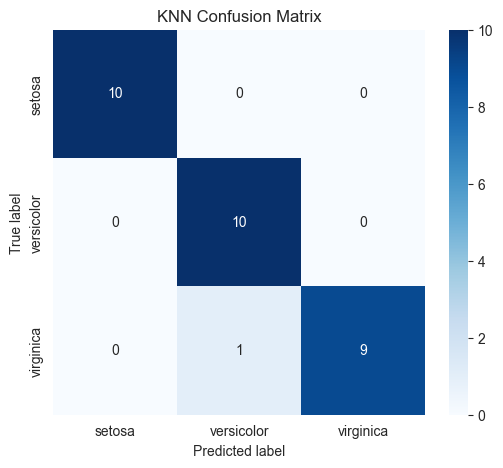

In [7]:
conf_mat = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('KNN Confusion Matrix')
plt.show()